## Analiza Produktów kosmetycznych 

##### Żródło Kaggle: https://www.kaggle.com/datasets/waqi786/most-used-beauty-cosmetics-products-in-the-world 

<div align ="justify">

Kilka słów o zbiorze danych - jest to fikcyjny zbiór danych (mock data), opublikowany w celach edukacyjnych. Dane te charakteryzują się idealnym zbalansowaniem, sa poprawne politycznie, lecz realnie odbiegają od realiów rynkowych. Zdecydowałam się na ten zbiór danych w celu nauki bibliotek Pandas, Numpy, Matplotlib oraz Seaborn oraz praktycznego wykrzystania wiedzy zdobytej podczas samodzielnej nauki.


<div align ="justify">

Analiza danych kosmetycznych pozwala zrozumieć, jak klienci wybierają produkty, które marki budzą największe zaufanie i jakie trendy faktycznie kształtują rynek beauty. W moim projekcie wykorzystuję syntetyczny zbiór danych, aby prześledzić zachowania konsumentów, ocenić jakość produktów i odkryć zależności, które mogą wspierać decyzje biznesowe. Dzięki analizie firmy mogą lepiej projektować ofertę, dopasowywać komunikację marketingową i przewidywać, które kategorie będą rosnąć oraz w co warto zainwestować. To także świetny sposób, by sprawdzić, czy cena naprawdę idzie w parze z jakością i które składniki są aktualnie na topie... a skoro o topie mówimy, to zacznijmy od najważniejszego...



##### Przygotowanie i czyszczenie danych 

Zanim przejdziemy do analizy, musimy upewnić się, że dane są poprawnie wczytane i gotowe do dalszej pracy. To fundament każdej analizy — błędne wczytanie danych prowadzi do błędnych wniosków,a tych przecież nie chcemy. Zacznijmy od zaimportowania modułów niezbędnych do analizy i wizualizacji danych

</div>


In [16]:
# import modułów
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from custom_styles import colors

# wczytanie pliku
df = pd.read_csv("top_beauty.csv")
df.head()

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany


<div align = "Justify">

Po wczytaniu danych czas się z nimi zapoznać, poprzez poniższe polecenia można sprawdzić:
* **'df.info()' - pozwoli zapoznac się z infomacjami o Data Frame
* **'df.isnull().sum()' - sprawdzimy czy są nulle i ile ich jest w poszczególnych kolumnach
* **'df.descibe()' - możemy zobaczyć podstawowe statystyki jak średnia, mediana, odchylenie standardowe i kwartyle

Teraz gdy wiemy, że dane są czyste - nie ma pustych wartości (nulli) i dodatkowo znamy podstawowe metryki statystyczne można przejść do analizy.

</div>

In [17]:
df.describe()


,Price_USD,Rating,Number_of_Reviews
count,15000.000000,15000.000000,15000.000000
mean,80.134108,3.002327,5014.231333
std,40.402983,1.168029,2855.665464
min,10.000000,1.000000,52.000000
25%,45.480000,2.000000,2562.000000
50%,80.040000,3.000000,5002.000000
75%,114.760000,4.000000,7497.000000
max,149.990000,5.000000,10000.000000


##### 1. Które firmy miały najwięcej pozytywnych recenzji. - Top 5

<div align = "Justify">

Te pytanie pozwala zidentyfikować liderów rynku — marki, które budują najwyższe zaufanie klientów. To kluczowe przy planowaniu współprac, kampanii marketingowych i rekomendacji produktowych.

</div>

In [18]:
top5 = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)
print(top5.head(5))

Brand
Milk Makeup      3.146479
Laura Mercier    3.141127
Hourglass        3.113934
Becca            3.100000
Shiseido         3.090541
Name: Rating, dtype: float64


##### 2. W jakiej kategorii produkty oceniane są najlepiej?

<div align = "Justify">

Pozwala określić, które segmenty rynku są najbardziej doceniane przez klientów — np. makijaż, pielęgnacja, perfumy. To pomaga firmom inwestować w najbardziej perspektywiczne linie produktów.

Zdecydowałam się użyć wykresu słupkowego (sns.barplot) z racji, że jest to najbardziej intuicyjne narzędzie do przedstawiania różnic wartości pomiedzy różnymi kategoriami - łatwośc porównania - długość słupka determinuje lidera rankingu. Z racji, że dane sa z fikcyjnego datasetu mamy tutaj małe rozbieżności pomiędzy poszczególnymi kategoriami. 

</div>

Category
Contour          3.129305
Moisturizer      3.079467
CC Cream         3.073064
BB Cream         3.060359
Setting Spray    3.050161
Name: Rating, dtype: float64


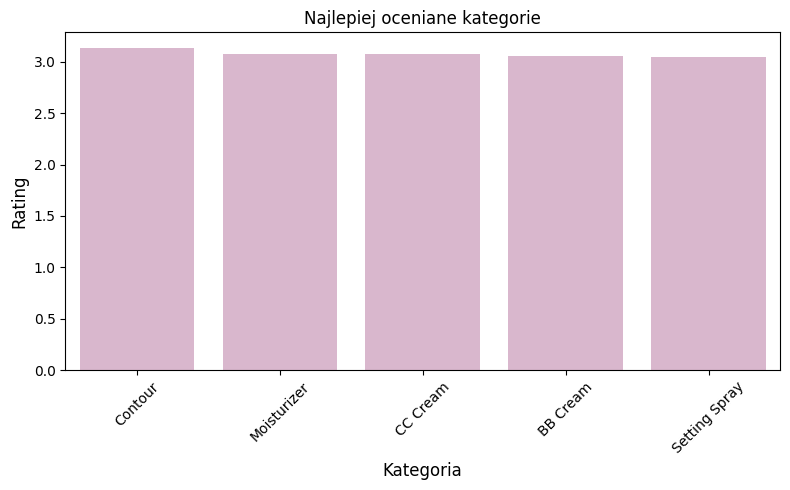

In [19]:
top_cat = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(5)
df_ct = top_cat.to_frame()
print(top_cat)

# 2. Wykres dla top5 kategorii:

# własna paleta barw:
sns.set_palette(sns.color_palette(colors))

#wykres
plt.figure(figsize=(8,5))
sns.barplot(data=df_ct,
            x='Category',
            y='Rating',
            #palette='viridis',
            errorbar=None,
            alpha=0.7)
plt.xticks(rotation=45)
plt.title('Najlepiej oceniane kategorie')
plt.xlabel('Kategoria', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.tight_layout()

plt.show()

##### 3. Średnia cena poroduktów

<div align = "Justify">

Zanim przejdziemy do dalszej analizy zobaczmy jaka jest średnia cena produktu i czy jest bliska medianie, czyli cenie która występuje najczęściej.

</div>

In [20]:
# średnia cena i mediana
avg_price = df['Price_USD'].mean()  
median_price = df['Price_USD'].median()
print(f"Średnia cena produktu to {avg_price.round(2)}.")
print(f"Cena, którą zobaczymy na sklepowej półce najczęściej to {median_price.round(2)}.")


Średnia cena produktu to 80.13.
Cena, którą zobaczymy na sklepowej półce najczęściej to 80.04.


<div align = "Justify">

Taki wynik, gdzie średnia cena produktu i mediana produktu są do siebie zbliżone oznacza, że rozkład danych jest symetryczny -  dane rozkładają się równomiernie po obu stronach wartości środkowej. Prawdopodobnie nie ma w nim outlierów (wartości skrajnych), a produkty wyceniane są w sposób przewidywalny dla konsumenta. To tzw. "normalność cenowa".

Aby w pełni zobrazować jak rozkładały się ceny produktów, możemy posłuzyć się histogramem, którey zobrazuje jak przezentowały się przedziały cenowe.

</div>

<Figure size 1600x1200 with 0 Axes>

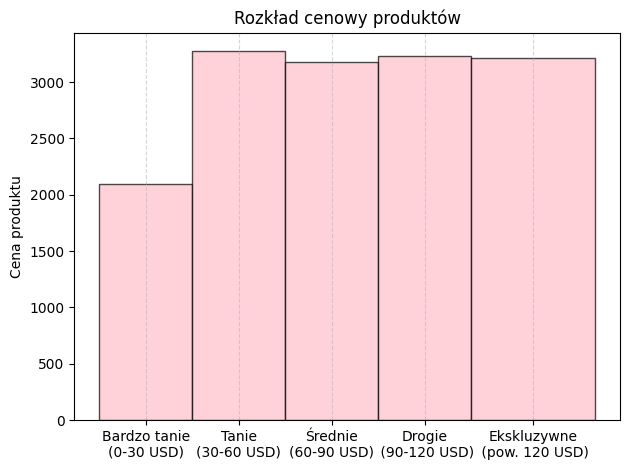

In [21]:
#definiowanie zmiennych
cena = df['Price_USD']
price_interval = [0, 30, 60, 90, 120, 160]
price_int_names = ['Bardzo tanie\n(0-30 USD)', 
                   'Tanie\n(30-60 USD)',
                   'Średnie\n(60-90 USD)',
                   'Drogie\n (90-120 USD)',
                   'Ekskluzywne\n (pow. 120 USD)']

plt.figure(figsize=(16, 12))
fig, ax = plt.subplots()

# histogram - przediały cenowe
ax.hist(cena, 
        alpha=0.7, 
        label="Cena produktu", 
        color='pink', 
        edgecolor= 'black',
        bins=price_interval)

#środki przedziałów:
middle_int = [(price_interval[i] + price_interval[i+1])/2 for i in range(len(price_interval)-1)]

# nazwy osi x
x_names = ['Bardzo tanie\n(0-30 USD)', 
                   'Tanie\n(30-60 USD)',
                   'Średnie\n(60-90 USD)',
                   'Drogie\n (90-120 USD)',
                   'Ekskluzywne\n (pow. 120 USD)']

ax.set_ylabel("Cena produktu")
ax.set_title("Rozkład cenowy produktów")
plt.xticks(middle_int, price_int_names)
plt.grid(axis = 'x',
        linestyle = '--',
        alpha=0.5 )
plt.tight_layout()
plt.show()

##### 4. Top 5 produktów - Identyfikacja segmentu premium!

<div align = "Justify">

Znalezienie produktów premium/luksusowych jest ważne dla strategii cenowych, pozycjonowania i analizy konkurencji.

</div>

In [22]:
expensive_cat = df.groupby('Product_Name')['Price_USD'].max().head(5)
print(expensive_cat)

Product_Name
Divine BB Cream    149.60
Divine Blush       146.01
Divine Bronzer     149.26
Divine CC Cream    149.73
Divine Cleanser    149.36
Name: Price_USD, dtype: float64


<div align = "Justify">

Powyższa analiza wskazuje jednoznacznie, że produkty premium to Divine, a ich ceny często przekraczają 140 USD, podczas gdy średnia cena produktów makijażowych to ok. 80 USD. Można więc powiedzieć, że kosmetyki Divine są prawie 60% droższe niż 'średniaki'. 

</div>

##### 5. Czy cena wpływa na pozytywne opinie? (rating ≥ 4.8)?

<div align = "Justify">

Sprawdźmy czy wyższa cena produktu idzie w parze z oceną klientów. Żeby odpowiedzieć na to pytanie posłużmy się korelacja między ceną produktu, a pozytywnymi opiniami. 

Korelacja - to związek miedzy dwoma zmiennymi, który pozwala ocenić, czy zmiana jednej zmiennej, wpływa na zmianę drugiej zmiennej. Współczynnik korelacji przyjmuje wartości od -1 do 1, gdzie wartości zbliżone do zera oznaczają, że zmienne nie wpływają na siebie, lub wpływają nieznacznie.

Dla celu badawczego uznaliśmy, że pozytywne opinie to te, które mają rating >=4.8.

</div>

In [23]:
pos = df[df['Rating']>=4.8]

price_review = pos['Price_USD'].corr(pos['Rating'])
print(f'Zależnosc oceny produktu od ceny {price_review:.3f}.')


Zależnosc oceny produktu od ceny -0.024.


<div align = "Justify">

Korelacja na poziomie -0.024 oznacza, że cena produktu nie ma wpływu na pozytywny odbiór konsumentów, a nawet nieznacznie go obniża. Możemy więc zatem przypuszczać, że czym większa cena, tym większe oczekiwania klientów, co jest logiczne.

</div>

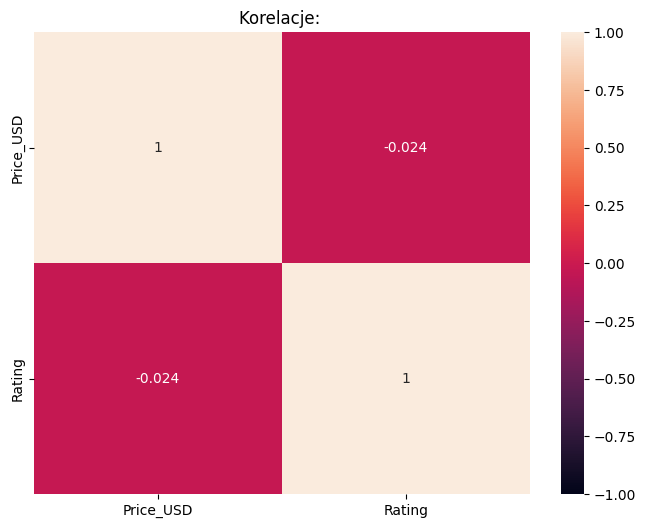

In [24]:
#dane wejsciowe dla korelacji
pos = df[df['Rating']>=4.8]
df_corr = pos[['Price_USD', 'Rating']].corr()

#tworzymy wykres
plt.figure(figsize=(8, 6))

#moduł seaborn
sns.heatmap(
    df_corr,                    # korelacja - dane wejciowe
    annot=True,                 # wartoci liczbowe wewnątrz kwadracików
    vmin=-1,                    # min wartoć skali kolorów
    vmax=1                      #maksymalna wartoć skali kolorów
)

plt.title("Korelacje: ")
plt.show()

##### 6. Produkty dla kobiet vs mężczyzn vs unisex - czy mamy balans?

<div align = "Justify">

Pozwala ocenić, czy oferta jest zbalansowana i czy marki trafiają do wszystkich grup odbiorców. Z racji, że dataset jest 'poprawny politycznie' mamy bardzo zbliżone dane. Zdecydowałam się na wykres kołowy, bo pozwala on określić jaką częścią całości (całej oferty) jest dana kategoria np. produkty skierowane do kobiet.

</div>

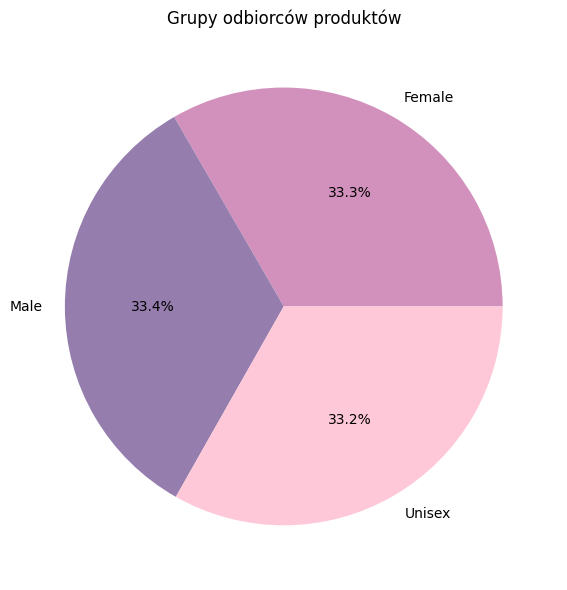

In [25]:
plt.figure(figsize=(8,6))

sns.set_palette(sns.color_palette(colors))

gender_target = df.groupby('Gender_Target')['Gender_Target'].count().plot(kind='pie',
                                                figsize=(10,6),
                                                subplots=True,
                                                autopct='%1.1f%%',
                                                #cmap='PuRd'
                                                )

plt.title('Grupy odbiorców produktów')
plt.tight_layout()
plt.show()

##### 7. Które produkty są najlepiej oceniane?

<div align = "Justify">

Pokazuje, które produkty są „gwiazdami” rynku — idealne do rekomendacji, kampanii i analiz trendów.

W celu wiarygodnego przedstawienia danych zdecydowałam się wziąć pod uwagę tylko te produkty, które mają więcej niż 5 pozytywnych ocen. 

</div>

In [26]:
#sprawdzamy średnią ocenę oraz liczbę recenzji
top_products = df.groupby(['Product_Name', 'Brand'])['Rating'].agg(['mean', 'count'])

#filtrowanie, zostawiamy produkty mające wiecej niż 5 recenzji
stars = top_products[top_products['count']>5]

#sortowanie wyników po najwyżeszj średniej ocen
print(stars.sort_values(by='mean', ascending=False).head(5))

                                         mean  count
Product_Name          Brand                         
Ultra CC Cream        Bite Beauty    4.171429      7
Divine Setting Spray  Morphe         4.116667      6
Perfect Face Mask     NARS           4.100000      6
Divine Makeup Remover Laura Mercier  4.100000      6
Perfect Lip Liner     Huda Beauty    4.042857      7


<div align = "Justify">

Wiemy już, któreprodukty są gwiazdami rynku, na pierwszym miejscu pojawiła się krem Ultra CC Cream, a zaraz za nim kosmetyk marki premium Divine Setting Spray. łatwo zauważyć, że najlepiejoceniane są produkty makijażowe, takie które dają szybki efekt wizualny... z kolei produkty do codziennej pielęgnacji cieszą się mniejszym uznaniem. Może dlatego, że na ich efekty trzeba poczekać, a wielu z nas brakuje cierpliwości. 

</div>

##### 8. Kraj pochodzenia a etyczność (cruelty-free)

<div align = "Justify">

Analiza ESG — coraz ważniejsza dla inwestorów i konsumentów. Pozwala ocenić, które kraje/marki stosują bardziej etyczne rozwiązania.

</div>

['Product_Name', 'Brand', 'Category', 'Usage_Frequency', 'Price_USD', 'Rating', 'Number_of_Reviews', 'Product_Size', 'Skin_Type', 'Gender_Target', 'Packaging_Type', 'Main_Ingredient', 'Cruelty_Free', 'Country_of_Origin']


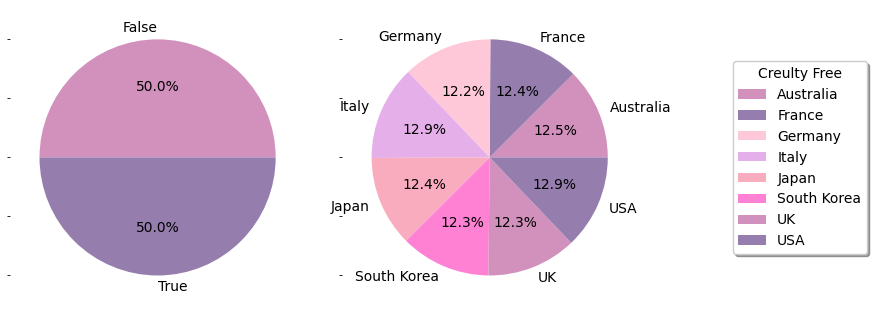

In [27]:
country_c_free = df.groupby(['Cruelty_Free' , 'Country_of_Origin']).count()

# pivotka
pivot_ccf = df.pivot_table(index='Cruelty_Free', 
                     columns='Country_of_Origin',
                     aggfunc='size',
                     fill_value=0)

print(df.columns.tolist())

#    1 - ile wierszy  # 2 - ile kolumn   #sharey - o y jest dzielona

country_counts = df.groupby('Country_of_Origin').size()

sns.set_palette(sns.color_palette(colors))

fig, ax = plt.subplots(1, 2, 
                       figsize=(10, 4),
                       sharey=True)  
fig.tight_layout(rect=[0, 0, 0.7, 0.9])

# wykres 1
pivot_ccf.groupby('Cruelty_Free').size().plot(ax=ax[0], 
                                              kind='pie',
                                              autopct='%1.1f%%',
                                              color='pink')
                                              #cmap='viridis')  
# wykres 2
country_counts.plot(ax=ax[1], 
                    kind='pie',
                    autopct='%1.1f%%',
                    color='pink'
                    )
# legenda
ax[1].legend('Cruelty Free')

plt.legend(title="Creulty Free",
           frameon=True,
           shadow=True,
           loc="center left",
           bbox_to_anchor=(1.3, 0.5))
plt.show()


<div align = "Justify">

Patrząc na powyższe dane, nie da się jednoznacznie wskazać etycznego lidera. To co najbardziej rzuca się w oczy, że już 50% rynku stosuje się do etycznych zasad produkcji kosmetyków, a trend ten wyszedł już poza Europę i Stany zjednoczone. Zgodnie z badaniem Grand View Research odnośnie "rynku kosmetyków nietestowanych na zwierzętach": https://www.grandviewresearch.com/industry-analysis/cruelty-free-cosmetics-market-report rynek kosmetyków 'cruelty-free" osiagnął wartość  ponad 14 miliardów dolarów USD i przewiduje się, że będzie rósł w stałym tempie wynoszącym 6,8% rocznie, do 2030 roku. 

</div>

##### 9. Główny składnik a typ skóry.

<div align = "Justify">

Ta informacja pomaga markom dopasować składniki do potrzeb klientów i tworzyć bardziej trafione produkty.

</div>

In [28]:
main_ing = df.groupby(['Skin_Type'])['Main_Ingredient'].agg(lambda x: x.value_counts().idxmax()).reset_index(name='Most_Common_Ingredient')
print(main_ing)


     Skin_Type Most_Common_Ingredient
0  Combination                Retinol
1          Dry              Vitamin C
2       Normal               Glycerin
3         Oily                Retinol
4    Sensitive              Vitamin C


##### 10. Znajdźmy najlepszy produkt dla skóry wrażliwej.

<div align = "Justify">

Kluczowe dla segmentu „sensitive skin”, który rośnie najszybciej w branży beauty.

</div>

In [29]:
best = df[df['Skin_Type'] == 'Sensitive']

best_sen = best.sort_values(by='Rating', ascending=False).head(5).reset_index()
best_sen_chosen = best_sen[['Product_Name', 'Brand', 'Category', 'Rating', 'Price_USD']]
print(best_sen_chosen)

         Product_Name               Brand     Category  Rating  Price_USD
0        Divine Blush     Kylie Cosmetics  Moisturizer     5.0     106.31
1       Ultra Bronzer  Yves Saint Laurent     Face Oil     5.0      99.64
2      Magic Lipstick               Becca  Moisturizer     5.0      95.40
3   Magic Highlighter               Becca      Bronzer     5.0      94.06
4  Perfect Exfoliator         Ilia Beauty      Mascara     5.0     121.76


<div align = "Justify">

Najlepszymi produktami dla skóry wrażliwej okazały się pomadki i błyszczyki – być może dlatego, ze skóra wrażliwa jest jak sama nazwa mówi, wymagająca i znalezienie odpowiedniego kosmetyku jest niezwykle trudne. 
W przypadku produktów do ust nie ma większego ryzyka alergii, czy zaczerwienienia, ze względu na typ tkanek, co czyni go uniwersalnym produktem nawet dla osób o wrażliwej czy alergicznej skórze 😊

</div>

##### 11. Jakie są główne składniki aktywne dydykowane dla różnych typów cery?

<div align = "Justify">

Zobaczmy proszę jakie składniki dominują w produktach dedykowanych dla każdego typu cery.

</div>

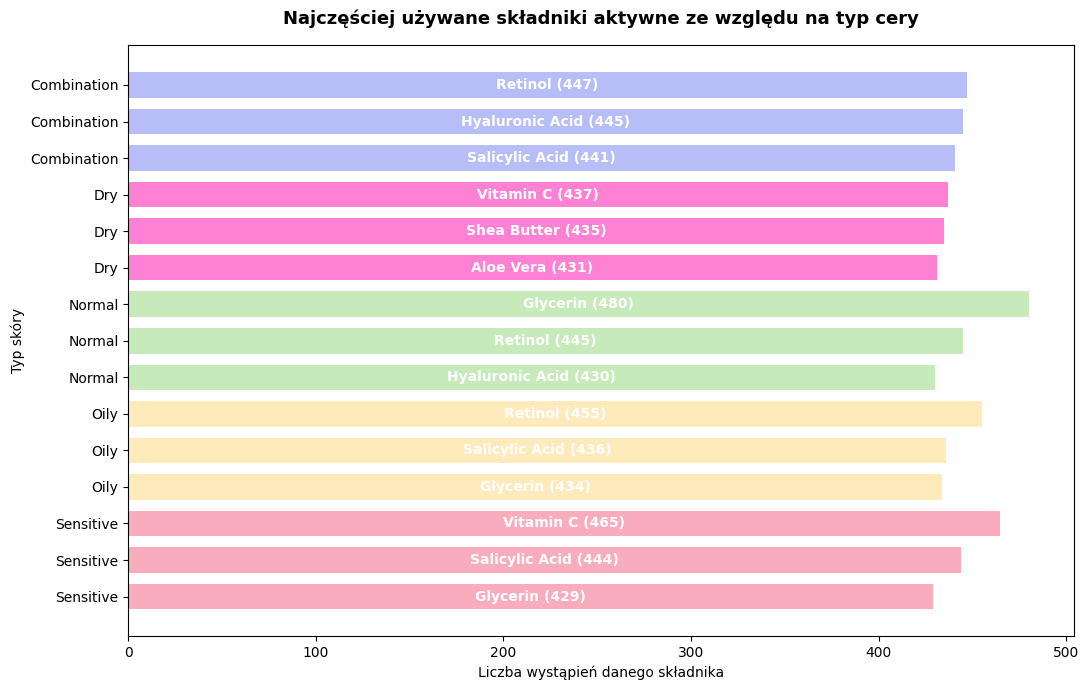

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Stacked Bar Chart - skumulowany wykres słupkowy

# przygotowanie danych

df_top3_skin = (
df.groupby("Skin_Type")["Main_Ingredient"]
    .value_counts()
    .groupby(level=0)
    .head(3)
    .reset_index(name="liczba produktów")
)

#sortowanie po typie skóry
df_top3_skin = df_top3_skin.sort_values(
                                        by=["Skin_Type", "liczba produktów"], 
                                        ascending=[True, False]
                                        ).reset_index(drop=True)

# moja paleta kolorystyczna - słownik
kolory={'Combination':'#B7BDF7', 
        'Dry':'#FE81D4',
        'Normal': '#C7EABB',
        'Oily' :'#FFEABB',
        'Sensitive': '#FAACBF'}

# rysowanie wykresu
plt.style.use("default")
plt.figure(figsize=(11, 7))

#lista kolorów i przypisanie do typu skóry
colors_list = [kolory[skin] for skin in df_top3_skin["Skin_Type"]]

# histogram
bars = plt.barh(
    df_top3_skin.index,
    df_top3_skin["liczba produktów"],
    color=colors_list,
    height=0.7,
)

# napisy na pasku

labels = [f"{row['Main_Ingredient']} ({int(row['liczba produktów'])})"
         for _, row in df_top3_skin.iterrows()]

# funkcja bar_label - do napisów na pasku
plt.gca().bar_label(
    bars,
    labels=labels,
    label_type="center",
    fontsize=10,
    weight="bold",
    color="white",
)


# oś Y typy skóry
plt.yticks(df_top3_skin.index, df_top3_skin["Skin_Type"])

# tytuł wykresu, labelki
plt.title("Najczęściej używane składniki aktywne ze względu na typ cery",
          fontsize=13,
          weight="bold",
          pad=15)
plt.xlabel("Liczba wystąpień danego składnika")
plt.ylabel("Typ skóry")

# odwrócenie osi Y
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

<div align = "Justify">

Retinol to główny składnik produktów dedykowanych dla skóry mieszanej i tłustej (ze względu na właściwości złuszczające i regulujące produkcję sebum), z kolei witamina C to główny składnik produktów do pielęgnacji skóry wrażliwej 
i suchej (ze względu właściwości przeciwzapalne). Skóra normalna jako najmniej wymagająca, nie potrzebuje większego wsparcia, nie jest zatem zaskoczeniem, że głównym składnikiem jest najzwyklejsza gliceryna. 😊

</div>

<div align = "Justify">

<u>Podsumowanie: </u>
- **Średnia cena produktu to ok 80.00 USD
- **za markę premium możemy uznać Divine, której kosmetyki kosztują ponad 140 USD 💰
- **Najlepsze produkty według ocen klientów to Milk Makeup i Laura Mercier ⭐
- **Wyższa cena to wyższe wymagania, a co za tym idzie - czym droższy kosmetyk, tym wieksze prawdopodobieństwo, że ocena klientow będzie surowsza. Mimo to, rynek pokazuje, że firmy inwestują w droższe produkty, a te uważane za bardzo tanie (do 30 USD) i tanie ( od 30 do 60 USD) mają najmniejszy udział w rynku. 📊
- **do kategorii bezpiecznych dla biznesu należą "konturowanie" i "kremy BB" - kosmetyki z tych kategorii mają najlepsze oceny wśród klientów - reklama robi się sama 😊
- **kraje wprowadzają etyczne sposoby produkcji kosmetyków, ale nie da się wybrać lidera 🌍
- ** rynek produktów 'Cruelty Free' będzie rósł - możliwe, że w nowszej wersji Data Setu, będziemy mieli już bardziej pozytywne dane
- **oferta produktów dedykowanych dla mężczyzn, kobiet oraz 'Unisex" jest praktycznie taka sama, mamy więc tutaj prawdziwe równouprawnienie 🚻
- **najlepszymi produktami do cery wrażliwej okazały się błyszczyki i pomadki, które zajeły 2 z 5 miejsc w rankingu konsumentów
- **do najczęściej stosowanych składników aktywnych należą: kwas hialuronowy, gliceryna, kwas salicylowy 🧴
- **Klienci najlepiej oceniają produkty makijażowe, które tuszują niedoskonałości i poprawiają wygląd, z kolei pielęgnacja, która wymaga czasu jest oceniana znacznie słabiej. Można więc założyć, że w tych czasach, sporo osób liczy na szybki i spektakularny efekt zamiast inwestować w rozwiązania długoterminowe, a szkoda, bo te przynoszą znacznie lepszy  i  trwalszy rezultat. 💄


</div>